In [56]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║                    09_curve_comparison.ipynb                               ║
# ║  Overlay training curves across multiple configurations for comparison     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

In [57]:
# ── Imports ───────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from pathlib import Path

from brainvision.constants import *
from brainvision.utils import build_run_name

RESULTS_DIR = Path(RESULTS_DIR)

In [58]:
# ══════════════════════════════════════════════════════════════════════════════
#                     CONFIGURE COMPARISON HERE
# ══════════════════════════════════════════════════════════════════════════════

# Each entry is one configuration to compare.
# Keys: model, loss, strategy, reduce_pixels, fold
# label: short name shown in legend (auto-generated if omitted)
# color: line colour (auto-assigned if omitted)

CONFIGURATIONS = [
    {
        'model'         : '1D-NN',
        'loss'          : 'CE',
        'strategy'      : 'vp_fabelo',
        'reduce_pixels' : True,
        'fold'          : 4,
        'label'         : '1D-NN × CE × bal',
        'color'         : '#378ADD',
    },
    {
        'model'         : '1D-NN-Fabelo',
        'loss'          : 'CE',
        'strategy'      : 'vp_fabelo',
        'reduce_pixels' : True,
        'fold'          : 4,
        'label'         : '1D-NN-Fabelo × CE × bal',
        'color'         : '#D85A30',
    },
    # {
    #     'model'         : '2D-CNN-Fabelo',
    #     'loss'          : 'CE',
    #     'strategy'      : 'vp_fabelo',
    #     'reduce_pixels' : True,
    #     'fold'          : 1,
    #     'label'         : 'FabeloCNN × CE × bal',
    #     'color'         : '#5DCAA5',
    # },
    # {
    #     'model'         : '2D-CNN-Fabelo',
    #     'loss'          : 'CE',
    #     'strategy'      : 'vp_fabelo',
    #     'reduce_pixels' : False,
    #     'fold'          : 1,
    #     'label'         : 'FabeloCNN × CE × nobal',
    #     'color'         : '#7F77DD',
    #     'linestyle'     : '--',    # optional — dashes to distinguish nobal
    # },
]

# Which metrics to plot — one subplot per metric
# Available: train_loss, val_loss, val_f1, val_f1_no_bg,
#            val_dice_no_bg, val_sens, val_spec
METRICS = [
    ('val_f1_no_bg',   'Val F1 no-BG',      (0, 1)),
    ('val_dice_no_bg', 'Val Dice no-BG',     (0, 1)),
    ('val_sens',       'Val Sensitivity',    (0, 1)),
    ('val_spec',       'Val Specificity',    (0, 1)),
    ('train_loss',     'Train Loss',          None),
    ('val_loss',       'Val Loss',            None),
]

In [59]:
# ── Auto-assign colours and styles ────────────────────────────────────
AUTO_COLORS = [
    '#378ADD', '#D85A30', '#5DCAA5', '#7F77DD',
    '#EF9F27', '#639922', '#888780', '#D85A30',
]

for i, cfg in enumerate(CONFIGURATIONS):
    if 'color'     not in cfg: cfg['color']     = AUTO_COLORS[i % len(AUTO_COLORS)]
    if 'linestyle' not in cfg: cfg['linestyle']  = '-'
    if 'label'     not in cfg:
        bal = 'bal' if cfg['reduce_pixels'] else 'nobal'
        fold_str = f"fold{cfg['fold']}" if cfg['fold'] else cfg['strategy']
        cfg['label'] = (f"{cfg['model']} × {cfg['loss']} × "
                        f"{bal} × {fold_str}")

In [60]:
from brainvision.history import load_history

print("Loading histories...")
loaded = []
for cfg in CONFIGURATIONS:
    h = load_history(cfg, RESULTS_DIR)
    if h is not None:
        loaded.append((cfg, h))
        n_epochs = len(h['train_loss'])
        best_ep  = h.get('best_epoch', '?')
        best_f1  = h.get('best_f1', float('nan'))
        print(f"  ✅ {cfg['label']:<35} "
              f"epochs={n_epochs}  best_ep={best_ep}  "
              f"best_f1_noBG={best_f1:.4f}")
    else:
        print(f"  ❌ {cfg['label']}")

print(f"\n{len(loaded)} / {len(CONFIGURATIONS)} configurations loaded")

Loading histories...
  ✅ 1D-NN × CE × bal                    epochs=36  best_ep=28  best_f1_noBG=0.6834
  ✅ 1D-NN-Fabelo × CE × bal             epochs=59  best_ep=44  best_f1_noBG=0.7050

2 / 2 configurations loaded


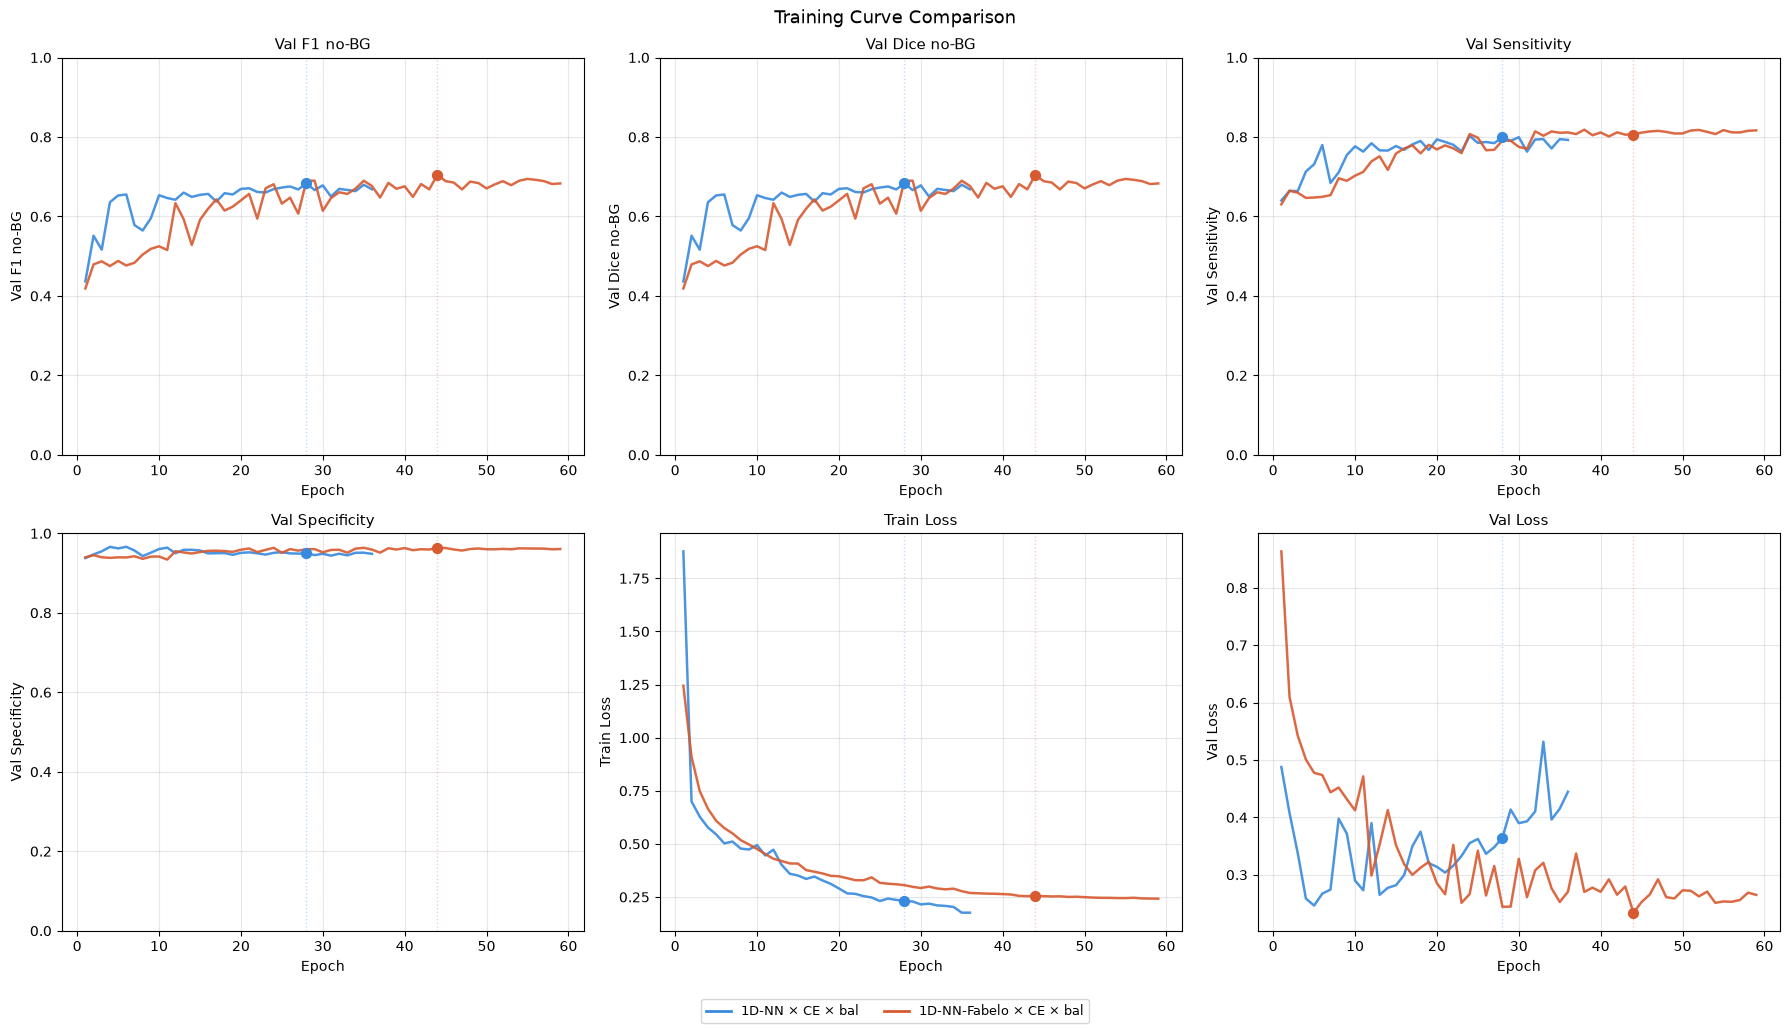

  Saved → ../results/curve_comparison_2configs.png


In [61]:

# ── Overlay comparison plot ───────────────────────────────────────────
def plot_curve_comparison(loaded_configs: list[tuple[dict, dict]],
                           metrics:        list[tuple],
                           title:          str = "Training Curve Comparison"):
    """
    Overlay training curves for all loaded configurations.

    Args:
        loaded_configs : list of (cfg, history) tuples
        metrics        : list of (history_key, label, ylim) tuples
        title          : figure title
    """
    n_metrics = len(metrics)
    n_cols    = 3
    n_rows    = (n_metrics + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(6 * n_cols, 5 * n_rows))
    axes      = axes.flatten() if n_metrics > 1 else [axes]
    fig.suptitle(title, fontsize=13)

    for ax_idx, (metric_key, metric_label, ylim) in enumerate(metrics):
        ax = axes[ax_idx]

        for cfg, history in loaded_configs:
            series = history.get(metric_key)
            if not series:
                continue

            epochs   = range(1, len(series) + 1)
            best_ep  = history.get('best_epoch', None)

            ax.plot(epochs, series,
                    color     = cfg['color'],
                    linestyle = cfg['linestyle'],
                    linewidth = 1.8,
                    label     = cfg['label'],
                    alpha     = 0.9)

            # Mark best epoch
            if best_ep and best_ep <= len(series):
                ax.scatter([best_ep], [series[best_ep - 1]],
                           color=cfg['color'], zorder=5, s=50)
                ax.axvline(best_ep, color=cfg['color'],
                           linestyle=':', alpha=0.3, linewidth=1)

        ax.set_title(metric_label, fontsize=11)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(metric_label)
        ax.grid(alpha=0.3)
        if ylim:
            ax.set_ylim(ylim)

    # ── Hide unused subplots ──────────────────────────────────────────────────
    for ax_idx in range(len(metrics), len(axes)):
        axes[ax_idx].axis('off')

    # ── Shared legend below the plot ──────────────────────────────────────────
    legend_handles = [
        mlines.Line2D([], [],
                      color     = cfg['color'],
                      linestyle = cfg['linestyle'],
                      linewidth = 2,
                      label     = cfg['label'])
        for cfg, _ in loaded_configs
    ]
    fig.legend(handles     = legend_handles,
               loc         = 'lower center',
               ncol        = min(len(loaded_configs), 3),
               fontsize    = 9,
               bbox_to_anchor = (0.5, -0.04))

    plt.tight_layout()
    out_path = RESULTS_DIR / f"curve_comparison_{len(loaded_configs)}configs.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")


if loaded:
    plot_curve_comparison(loaded, METRICS,
                          title="Training Curve Comparison")
else:
    print("No histories loaded — nothing to plot.")

In [62]:
# ── Best epoch summary table ─────────────────────────────────────────
def print_summary_table(loaded_configs: list[tuple[dict, dict]]):
    """Print best-epoch metrics for all configurations side by side."""
    if not loaded_configs:
        print("No configurations to summarise.")
        return

    from prettytable import PrettyTable
    table = PrettyTable()
    table.field_names = [
        "Configuration", "Best epoch", "F1 no-BG",
        "Dice no-BG", "Sensitivity", "Specificity", "Total epochs"
    ]
    table.align["Configuration"] = 'l'
    for col in table.field_names[1:]:
        table.align[col] = 'r'

    for cfg, history in loaded_configs:
        best_ep  = history.get('best_epoch', '?')
        n_epochs = len(history['train_loss'])

        def _best(key):
            series = history.get(key, [])
            if series and isinstance(best_ep, int) and best_ep <= len(series):
                return f"{series[best_ep-1]:.4f}"
            return "N/A"

        table.add_row([
            cfg['label'],
            best_ep,
            f"{history.get('best_f1', float('nan')):.4f}",
            _best('val_dice_no_bg'),
            f"{history.get('best_sens', float('nan')):.4f}",
            f"{history.get('best_spec', float('nan')):.4f}",
            n_epochs,
        ])

    print(f"\n{'═'*80}")
    print(f"  BEST EPOCH SUMMARY — {len(loaded_configs)} configurations")
    print(f"{'═'*80}")
    print(table)


print_summary_table(loaded)


════════════════════════════════════════════════════════════════════════════════
  BEST EPOCH SUMMARY — 2 configurations
════════════════════════════════════════════════════════════════════════════════
+-------------------------+------------+----------+------------+-------------+-------------+--------------+
| Configuration           | Best epoch | F1 no-BG | Dice no-BG | Sensitivity | Specificity | Total epochs |
+-------------------------+------------+----------+------------+-------------+-------------+--------------+
| 1D-NN × CE × bal        |         28 |   0.6834 |     0.6834 |      0.7993 |      0.9498 |           36 |
| 1D-NN-Fabelo × CE × bal |         44 |   0.7050 |     0.7050 |      0.8061 |      0.9638 |           59 |
+-------------------------+------------+----------+------------+-------------+-------------+--------------+


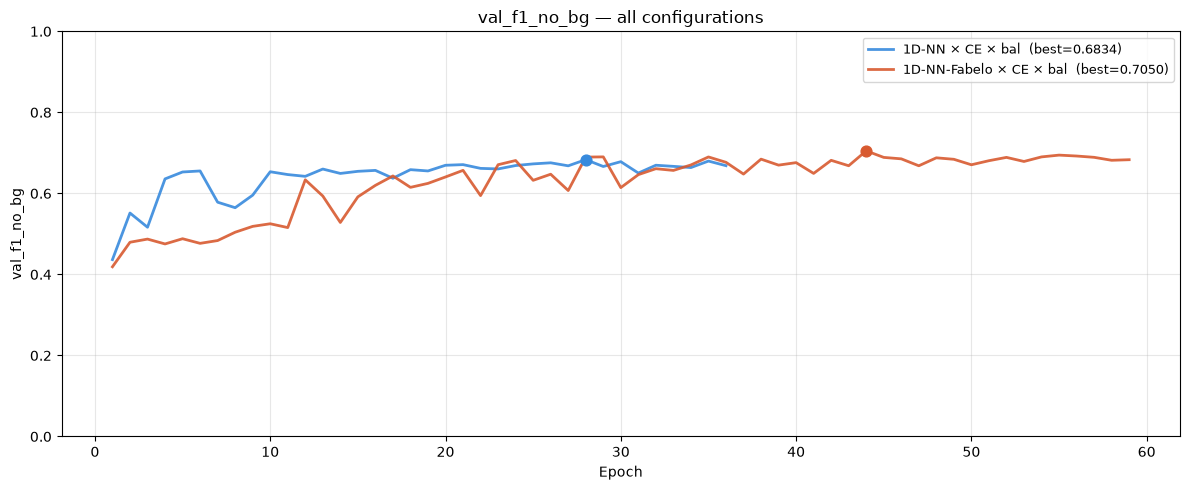

  Saved → ../results/focused_val_f1_no_bg_2configs.png


In [63]:
# ── Per-metric focused comparison ─────────────────────────────────────
# Useful for zooming in on one metric across all configurations

FOCUS_METRIC = 'val_f1_no_bg'   # change to any metric key

def plot_focused(loaded_configs: list[tuple[dict, dict]],
                 metric_key:     str,
                 metric_label:   str = None):
    """Single large plot of one metric across all configurations."""
    label = metric_label or metric_key

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.set_title(f"{label} — all configurations", fontsize=12)

    for cfg, history in loaded_configs:
        series = history.get(metric_key)
        if not series:
            continue

        epochs  = range(1, len(series) + 1)
        best_ep = history.get('best_epoch', None)
        best_v  = series[best_ep - 1] if best_ep and best_ep <= len(series) else None

        ax.plot(epochs, series,
                color     = cfg['color'],
                linestyle = cfg['linestyle'],
                linewidth = 2,
                label     = f"{cfg['label']}  (best={best_v:.4f})"
                            if best_v else cfg['label'],
                alpha     = 0.9)

        if best_ep and best_v:
            ax.scatter([best_ep], [best_v],
                       color=cfg['color'], zorder=5, s=60)

    ax.set_xlabel("Epoch")
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    if metric_key not in ('train_loss', 'val_loss'):
        ax.set_ylim(0, 1)

    plt.tight_layout()
    out_path = RESULTS_DIR / f"focused_{metric_key}_{len(loaded_configs)}configs.png"
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Saved → {out_path}")


if loaded:
    plot_focused(loaded, FOCUS_METRIC)